In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (184327, 10)
Columns: ['Voltage', 'Power_Factor', 'Power', 'ESP32_Temperature', 'CPU_Consumption', 'CPU_Power_Consumption', 'CPU_Temperature', 'RAM_Consumption', 'RAM_Power_Consumption', 'RAM_Temperature']


,Voltage,Power_Factor,Power,ESP32_Temperature,CPU_Consumption,CPU_Power_Consumption,CPU_Temperature,RAM_Consumption,RAM_Power_Consumption,RAM_Temperature
0,120.006557,0.968525,101.468852,0.873279,0.0,0.0,0.0,0.0,0.0,0.0
1,120.006557,0.972787,102.250820,0.876230,0.0,0.0,0.0,0.0,0.0,0.0
2,120.037705,0.958689,100.242623,0.870328,0.0,0.0,0.0,0.0,0.0,0.0
3,120.027869,0.944262,98.113115,0.865246,0.0,0.0,0.0,0.0,0.0,0.0
4,120.037705,0.943115,97.857377,0.863115,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
X = df.drop(columns=['Power'])
y = df['Power']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Features:", list(X.columns))

Training set size: (147461, 9)
Testing set size: (36866, 9)
Features: ['Voltage', 'Power_Factor', 'ESP32_Temperature', 'CPU_Consumption', 'CPU_Power_Consumption', 'CPU_Temperature', 'RAM_Consumption', 'RAM_Power_Consumption', 'RAM_Temperature']


In [3]:
print("="*40)
print("BASELINE 1: Linear Regression")
print("="*40)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print(f"MSE:  {lr_mse:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE:  {lr_mae:.4f}")
print(f"R²:   {lr_r2:.4f}")

BASELINE 1: Linear Regression
MSE:  1.3376
RMSE: 1.1566
MAE:  0.7303
R²:   0.9979


In [4]:
print("="*40)
print("BASELINE 2: Random Forest")
print("="*40)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"MSE:  {rf_mse:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")

BASELINE 2: Random Forest
MSE:  0.0187
RMSE: 0.1366
MAE:  0.0608
R²:   1.0000


In [5]:
print("="*40)
print("BASELINE 3: XGBoost")
print("="*40)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"MSE:  {xgb_mse:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE:  {xgb_mae:.4f}")
print(f"R²:   {xgb_r2:.4f}")

BASELINE 3: XGBoost
MSE:  0.0847
RMSE: 0.2910
MAE:  0.1081
R²:   0.9999


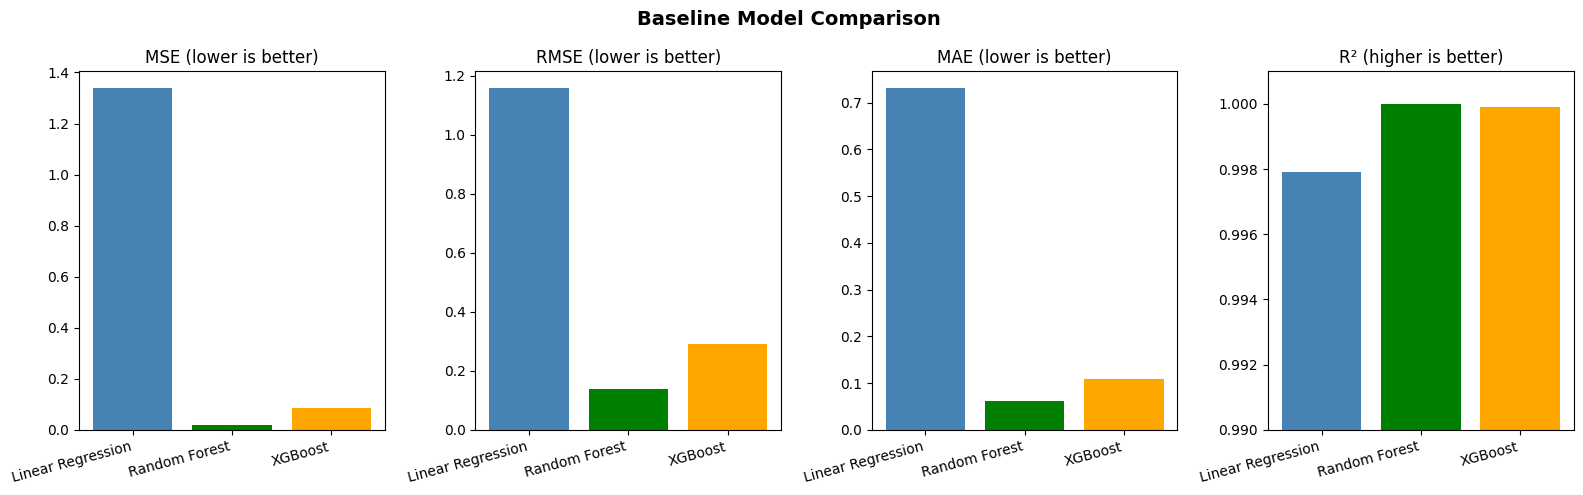

 Chart saved to results/baseline_comparison.png


In [6]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']

mse_scores = [1.3376, 0.0187, 0.0847]
rmse_scores = [1.1566, 0.1366, 0.2910]
mae_scores = [0.7303, 0.0608, 0.1081]
r2_scores = [0.9979, 1.0000, 0.9999]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# MSE
axes[0].bar(models, mse_scores, color=['steelblue', 'green', 'orange'])
axes[0].set_title('MSE (lower is better)')
axes[0].set_xticklabels(models, rotation=15, ha='right')

# RMSE
axes[1].bar(models, rmse_scores, color=['steelblue', 'green', 'orange'])
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xticklabels(models, rotation=15, ha='right')

# MAE
axes[2].bar(models, mae_scores, color=['steelblue', 'green', 'orange'])
axes[2].set_title('MAE (lower is better)')
axes[2].set_xticklabels(models, rotation=15, ha='right')

# R²
axes[3].bar(models, r2_scores, color=['steelblue', 'green', 'orange'])
axes[3].set_title('R² (higher is better)')
axes[3].set_xticklabels(models, rotation=15, ha='right')
axes[3].set_ylim([0.99, 1.001])

plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=150)
plt.show()

print(" Chart saved to results/baseline_comparison.png")

In [7]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MSE': [1.3376, 0.0187, 0.0847],
    'RMSE': [1.1566, 0.1366, 0.2910],
    'MAE': [0.7303, 0.0608, 0.1081],
    'R2': [0.9979, 1.0000, 0.9999]
})

results.to_csv('../results/baseline_results.csv', index=False)
print(" Results saved to results/baseline_results.csv")
print(results.to_string(index=False))

 Results saved to results/baseline_results.csv
            Model    MSE   RMSE    MAE     R2
Linear Regression 1.3376 1.1566 0.7303 0.9979
    Random Forest 0.0187 0.1366 0.0608 1.0000
          XGBoost 0.0847 0.2910 0.1081 0.9999
